<a href="https://colab.research.google.com/github/MaximeG2110/2026_Intro_Python/blob/main/live/part-I/FEEDBACK_GALLEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reflective exercise: Maxime Galley

> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [19]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

## Exercise 20: Historic significant earthquakes

The file cached below is NOAA's catalog of significant earthquakes, reaching back to 2150 BCE:
one row per event, tab-separated, 47 columns. The four you need are at positions 8
(`FOCAL_DEPTH`, km), 9 (`EQ_PRIMARY`, magnitude), 20 (`LATITUDE`) and 21 (`LONGITUDE`).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-scatter.png" alt="A scatter plot of earthquake longitude against latitude, coloured by the base-10 logarithm of focal depth and sized by magnitude" width="100%">

<em>The figure to replicate: every event as one point, coloured by the base-10 logarithm of its
focal depth and sized by its magnitude. No coastline is drawn — the plate boundaries are the
data.</em>


Rebuild it, and in a comment name the feature of the Earth that the points trace out.

In [24]:
# Pre-supplied: download the data file and cache it locally.
import pooch
import numpy as np
import matplotlib.pyplot as plt


path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

In [ ]:
# Hint: np.genfromtxt(path, delimiter="\t", skip_header=1) loads the whole file; every
#       non-numeric field becomes NaN, which is what you want here. Pull the four columns out
#       by position -- the focal depth, for example, is arr[:, 8]
# Hint: keep only the rows where depth and magnitude are both above zero and latitude and
#       longitude are not NaN. & combines two masks element-wise ("and"), and ~ flips one
#       ("not"), so ~np.isnan(latitude) is True wherever the latitude is present
# Hint: colour the points by np.log10 of the focal depth -- the base-10 logarithm, applied
#       element-wise, which spreads out depths from under a kilometre to several hundred --
#       and set the point area to the square of the magnitude
# Hint: add a labelled colorbar, axis labels, a title, and a dotted grid


## Exercice Resolution

(5958, 47)


/tmp/ipykernel_893/2823268085.py:19: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(focal_depth),


ValueError: s must be a scalar, or float array-like with the same size as x and y

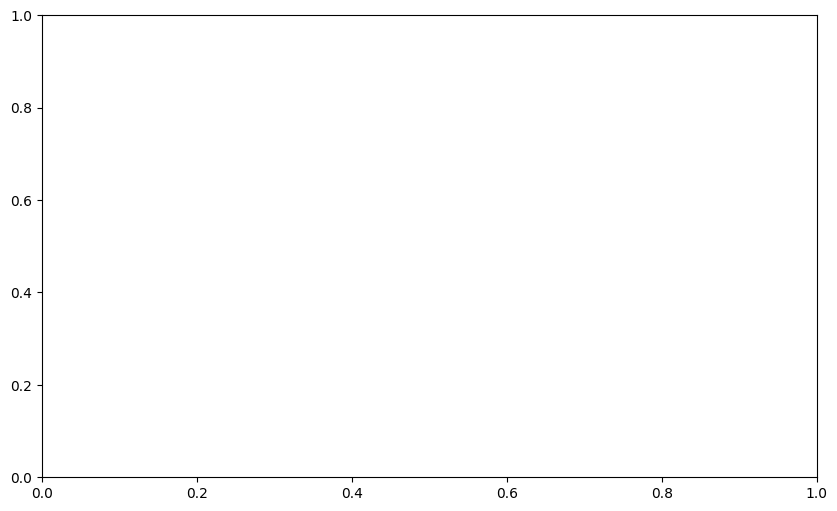

In [62]:
#loading data
arr = np.genfromtxt(path, delimiter="\t", skip_header=1)
print(arr.shape) #check shape

#extracting data and applying masks
focal_depth = arr[:,8]
focal_depth_pos = focal_depth[focal_depth > 0]
eq_primary_magnitude = arr[:, 9]
eq_primary_magnitude_pos = eq_primary_magnitude[eq_primary_magnitude > 0]
lat = ~np.isnan(arr[:, 20])
lon = ~np.isnan(arr[:, 21])

#creating the figure for the plot
fig, ax = plt.subplots(figsize=(10, 6))

#creating the scatterplot
sc = ax.scatter(
    lon, lat,
    c=np.log10(focal_depth),
    cmap="viridis",
    s=eq_primary_magnitude_pos,   #error comming from this part --> ValueError: s must be a scalar, or float array-like with the same size as x and y
    alpha=0.6,
)

#adding a colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Focal depth (km)")

#labelling the graph
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Séismes : profondeur (couleur) et magnitude (taille)")
ax.grid(alpha=0.3)

plt.show()

In [63]:
#I then checked the shape of the different variables

print(eq_primary_magnitude_pos.shape)

print(lon.shape)
print(lat.shape)

print(lon.dtype)
print(lat.dtype)
print(eq_primary_magnitude_pos.dtype)

#As we can see, the lon/lat shape is 5958x5958, but the shape of the magnitude array is 4170x1.
#This means we have array with different size, which doesn't work for the "scatter" plotting.
#Furthermore, we have different types of values (bool and float64). This is also a problem for the scatter plot.

#This error probably comes from the mask.
#After regarding it carefully, I understand that the error comes from the fact that I didn't apply the same mask on all variables.
#To correct that, I have to create a single mask and apply it on all variable.
#This is done in the following code.

(4170,)
(5958,)
(5958,)
bool
bool
float64


### Error resolution:

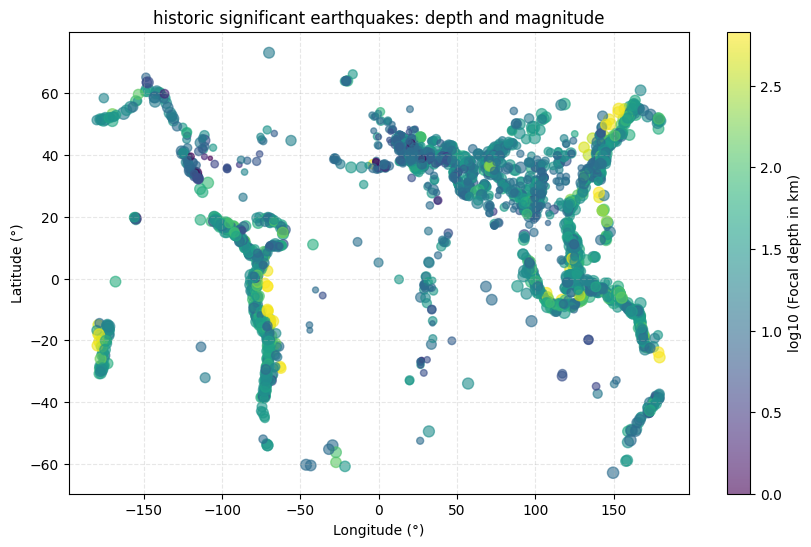

In [61]:
#loading the data
arr = np.genfromtxt(path, delimiter="\t", skip_header=1)

#extracting data
focal_depth = arr[:,8]
eq_primary_magnitude = arr[:, 9]
lat = arr[:, 20]
lon = arr[:, 21]

#creation of a single mask and applying it on all variables:
mask = (focal_depth > 0) & (eq_primary_magnitude > 0) & (~np.isnan(lat)) & (~np.isnan(lon))
lon = lon[mask]
lat = lat[mask]
focal_depth = focal_depth[mask]
eq_primary_magnitude = eq_primary_magnitude[mask]

#plotting
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    lon, lat,
    c=np.log10(focal_depth),
    cmap="viridis",
    s=eq_primary_magnitude**2,
    alpha=0.6,
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log10 (Focal depth in km)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("historic significant earthquakes: depth and magnitude")
ax.grid(alpha=0.3, linestyle="--")

plt.show()

In [64]:
#And everything works perfectly :)))